In [7]:
# Data Analyst project with python pandas and matplotlib
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv(r"C:\Users\kamal\AAGitvideos\messy_sales.csv")
df.head()
df.shape


(21, 10)

In [8]:
#  part 1 Inspecting the data
# 1 Number of rows and columns
df.shape

(21, 10)

In [9]:
#column names
df.columns

Index(['Order_ID', 'Order_Date', 'Customer', 'Product', 'Category', 'Quantity',
       'Unit_Price', 'Region', 'Payment', 'Discount'],
      dtype='str')

In [10]:
#Data types
df.dtypes


Order_ID      int64
Order_Date      str
Customer        str
Product         str
Category        str
Quantity        str
Unit_Price      str
Region          str
Payment         str
Discount        str
dtype: object

In [11]:
# 4 missing values in each column
df.isnull().sum()

Order_ID      0
Order_Date    0
Customer      0
Product       0
Category      0
Quantity      1
Unit_Price    0
Region        0
Payment       2
Discount      0
dtype: int64

In [12]:
#duplicate rows
df[df.duplicated(keep=False)]


,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
15,1016,2026-01-30,John,Keyboard,Electronics,1,25,South,Card,5%
16,1016,2026-01-30,John,Keyboard,Electronics,1,25,South,Card,5%


In [13]:
# 6 find unique values in region payment
df['Region'].unique()
df['Payment'].unique()
df['Product'].unique()
df['Category'].unique()

<StringArray>
['Electronics', 'Accessories']
Length: 2, dtype: str

In [14]:
#Part 2 -Clean the data


cleaned_df = df.copy()
cleaned_df 


,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.00,South,Card,5%
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,$15.50,south,Cash,0
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35,North,card,10%
3,1004,Jan 10 2026,John,Keyboard,Electronics,two,25,South,CARD,5%
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.50,South,NaN,0%
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,$35,North,Cash,5%
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.00,NORTH,Card,10%
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,card,0%
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,NaN,35,South,Cash,5%
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25,North,Card,5%


In [15]:
# Order Date - convert to proper date time format

cleaned_df['Order_Date'] = pd.to_datetime(cleaned_df['Order_Date'], format='mixed', errors='coerce')
print(cleaned_df)


    Order_ID Order_Date Customer       Product     Category Quantity  \
0       1001 2026-01-05    Anita      Keyboard  Electronics        2   
1       1002 2026-01-07     Ravi         Mouse  Electronics        3   
2       1003 2026-01-08    Meena  Laptop Stand  Accessories        1   
3       1004 2026-01-10     John      Keyboard  Electronics      two   
4       1005 2026-01-12    Anita         Mouse  Electronics        2   
5       1006 2026-01-13     Ravi  Laptop Stand  Accessories        1   
6       1007 2026-01-15    Meena      Keyboard  Electronics        3   
7       1008 2026-01-16     John         Mouse  Electronics        1   
8       1009 2026-01-18    Anita  Laptop Stand  Accessories      NaN   
9       1010 2026-01-20     Ravi      Keyboard  Electronics        2   
10      1011 2026-01-21    Meena         Mouse  Electronics        4   
11      1012 2026-01-22     John  Laptop Stand  Accessories        1   
12      1013 2026-01-25    Anita      Keyboard  Electronics     

In [40]:
# convert quantity to numberic . deal 'two'
cleaned_df['Quantity']= cleaned_df['Quantity'].fillna('0')

from word2number import w2n

def to_num(x):
    if isinstance(x, str):
        try:
            return w2n.word_to_num(x)
        except ValueError:
            return x                        # 无法解析就原样返回
    return x

cleaned_df['Quantity'] = cleaned_df['Quantity'].map(to_num)
cleaned_df['Quantity'] = pd.to_numeric(cleaned_df['Quantity'], errors='coerce')
cleaned_df


#cleaned_df['Quantity'] = pd.to_numeric(cleaned_df['Quantity'], errors='coerce')
#cleaned_df['Quantity'] 


,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.00,South,Card,5%
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,$15.50,South,Cash,0
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35,North,Card,10%
3,1004,Jan 10 2026,John,Keyboard,Electronics,2,25,South,Card,5%
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.50,South,NaN,0%
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,$35,North,Cash,5%
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.00,North,Card,10%
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,Card,0%
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,0,35,South,Cash,5%
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25,North,Card,5%


In [41]:
#unit price remove $ convert to numeric
cleaned_df['Unit_Price'] = cleaned_df['Unit_Price'].str.replace('$', '')
cleaned_df['Unit_Price'] = pd.to_numeric(cleaned_df['Unit_Price'], errors='coerce')
cleaned_df['Unit_Price']



0     25.0
1     15.5
2     35.0
3     25.0
4     15.5
5     35.0
6     25.0
7     15.5
8     35.0
9     25.0
10    15.5
11    35.0
12    25.0
13    15.5
14    35.0
15    25.0
16    25.0
17    15.5
18    35.0
19    25.0
20    15.5
Name: Unit_Price, dtype: float64

In [42]:
cleaned_df


,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.0,South,Card,5%
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,15.5,South,Cash,0
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35.0,North,Card,10%
3,1004,Jan 10 2026,John,Keyboard,Electronics,2,25.0,South,Card,5%
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.5,South,NaN,0%
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,35.0,North,Cash,5%
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.0,North,Card,10%
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,Card,0%
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,0,35.0,South,Cash,5%
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25.0,North,Card,5%


In [43]:
# region make first letter capitalized
#cleaned_df['Region'] = cleaned_df['Region'].str.lower().str.capitalize()

cleaned_df['Region'] = (
    cleaned_df['Region']
      .astype('string')
      .str.replace('\xa0', ' ', regex=False)   # non-breaking space -> plain space
      .str.strip()
      .str.capitalize()
)

cleaned_df

,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.0,South,Card,5%
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,15.5,South,Cash,0
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35.0,North,Card,10%
3,1004,Jan 10 2026,John,Keyboard,Electronics,2,25.0,South,Card,5%
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.5,South,NaN,0%
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,35.0,North,Cash,5%
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.0,North,Card,10%
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,Card,0%
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,0,35.0,South,Cash,5%
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25.0,North,Card,5%


In [44]:
#Payment make first letter capitalized, handle missing payment values
#cleaned_df=df.copy()
cleaned_df['Payment'] = cleaned_df['Payment'].str.lower().str.capitalize()
#cleaned_df['Payment'] = cleaned_df['Payment'].fillna('Na')
cleaned_df


,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.0,South,Card,5%
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,15.5,South,Cash,0
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35.0,North,Card,10%
3,1004,Jan 10 2026,John,Keyboard,Electronics,2,25.0,South,Card,5%
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.5,South,NaN,0%
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,35.0,North,Cash,5%
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.0,North,Card,10%
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,Card,0%
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,0,35.0,South,Cash,5%
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25.0,North,Card,5%


In [45]:
# Discount-convert to numeric, handle missing values
cleaned_df['Discount'] = cleaned_df['Discount'].str.replace('%', '')
cleaned_df['Discount'] = pd.to_numeric(cleaned_df['Discount'], errors='coerce')
cleaned_df['Discount']


0      5
1      0
2     10
3      5
4      0
5      5
6     10
7      0
8      5
9      5
10     0
11    10
12     5
13     0
14     5
15     5
16     5
17     0
18     5
19    10
20     0
Name: Discount, dtype: int64

In [22]:
#cleaned_df


,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.00,South,Card,5
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,$15.50,south,Cash,0
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35,North,Card,10
3,1004,Jan 10 2026,John,Keyboard,Electronics,two,25,South,Card,5
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.50,South,NaN,0
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,$35,North,Cash,5
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.00,NORTH,Card,10
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,Card,0
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,NaN,35,South,Cash,5
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25,North,Card,5


In [46]:
# duplicate order id 1016
#cleaned_df[cleaned_df['Order_ID'] == 1016]
cleaned_df.drop_duplicates()
cleaned_df = cleaned_df.drop_duplicates(subset=None, keep='first', inplace=False, ignore_index=False)
cleaned_df



,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.0,South,Card,5
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,15.5,South,Cash,0
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35.0,North,Card,10
3,1004,Jan 10 2026,John,Keyboard,Electronics,2,25.0,South,Card,5
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.5,South,NaN,0
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,35.0,North,Cash,5
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.0,North,Card,10
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,Card,0
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,0,35.0,South,Cash,5
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25.0,North,Card,5


In [47]:
cleaned_df.reset_index(drop=True, inplace=True )
cleaned_df



,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.0,South,Card,5
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,15.5,South,Cash,0
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35.0,North,Card,10
3,1004,Jan 10 2026,John,Keyboard,Electronics,2,25.0,South,Card,5
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.5,South,NaN,0
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,35.0,North,Cash,5
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.0,North,Card,10
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,Card,0
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,0,35.0,South,Cash,5
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25.0,North,Card,5


In [48]:
#missing values
cleaned_df.isnull().sum()


Order_ID      0
Order_Date    0
Customer      0
Product       0
Category      0
Quantity      0
Unit_Price    0
Region        0
Payment       2
Discount      0
dtype: int64

In [49]:
#Part 3 -create new column Net-Sales=Quantity * Unit_Price * (1 - Discount/100)
# Part 3 - create new column Net_Sales = Quantity * Unit_Price * (1 - Discount/100)
cleaned_df['Net_Sales'] = (
    cleaned_df['Quantity'].fillna(0).astype(int)
    * cleaned_df['Unit_Price'].fillna(0).astype(float)
    * (1 - cleaned_df['Discount'].fillna(0).astype(float) / 100)
)

cleaned_df
cleaned_df


,Order_ID,Order_Date,Customer,Product,Category,Quantity,Unit_Price,Region,Payment,Discount,Net_Sales
0,1001,2026-01-05,Anita,Keyboard,Electronics,2,25.0,South,Card,5,47.50
1,1002,01/07/2026,Ravi,Mouse,Electronics,3,15.5,South,Cash,0,46.50
2,1003,2026/01/08,Meena,Laptop Stand,Accessories,1,35.0,North,Card,10,31.50
3,1004,Jan 10 2026,John,Keyboard,Electronics,2,25.0,South,Card,5,47.50
4,1005,2026-01-12,Anita,Mouse,Electronics,2,15.5,South,NaN,0,31.00
5,1006,13-01-2026,Ravi,Laptop Stand,Accessories,1,35.0,North,Cash,5,33.25
6,1007,2026-01-15,Meena,Keyboard,Electronics,3,25.0,North,Card,10,67.50
7,1008,2026-01-16,John,Mouse,Electronics,1,15.5,South,Card,0,15.50
8,1009,2026-01-18,Anita,Laptop Stand,Accessories,0,35.0,South,Cash,5,0.00
9,1010,2026-01-20,Ravi,Keyboard,Electronics,2,25.0,North,Card,5,47.50


In [27]:
cleaned_df.dtypes

Order_ID      int64
Order_Date      str
Customer        str
Product         str
Category        str
Quantity        str
Unit_Price      str
Region          str
Payment         str
Discount      int64
dtype: object

In [52]:
#Part 4-Answer the Business Questions
#What is the total net sales?
total_net_sales = cleaned_df['Net_Sales'].sum()
print("Total net sales:", total_net_sales)
#What is the average order value?
average_order_value = cleaned_df['Net_Sales'].mean()
print("Average order value:", average_order_value)
#Which product generated the most sales?
product_most_sales=cleaned_df['Net_Sales'].groupby(cleaned_df['Product']).sum().idxmax()
print("Product generated the most sales:", product_most_sales)  
#Which region generated the most sales?
region_most_sales=cleaned_df['Net_Sales'].groupby(cleaned_df['Region']).sum().idxmax()
print("Region generated the most sales:", region_most_sales)
#Which month generated the most sales?
cleaned_df['Order_Date'] = pd.to_datetime(cleaned_df['Order_Date'], format='mixed', errors='coerce')
monthly = cleaned_df.groupby(pd.Grouper(key="Order_Date", freq="ME"))["Net_Sales"].sum()
print("Month generated the most sales:", monthly.idxmax())
#Which customer purchased the most?
customer_most_sales=cleaned_df['Net_Sales'].groupby(cleaned_df['Customer']).sum().idxmax()
print("Customer purchased the most:", customer_most_sales)  
#How many orders were paid by Card vs Cash?
payment_counts = cleaned_df['Payment'].value_counts()
payment_counts
#print("Orders paid by Card:", payment_counts.get('Card', 0))    
#print("Orders paid by Cash:", payment_counts.get('Cash', 0))   
# 
# What percentage of orders are missing payment information?
# NaN cells (truly blank in the CSV)
PercentMissingPaymentInfo = cleaned_df['Payment'].isna().sum() / len(cleaned_df) * 100
print("Percentage of orders missing payment information:", PercentMissingPaymentInfo)


Total net sales: 801.25
Average order value: 40.0625
Product generated the most sales: Keyboard
Region generated the most sales: North
Month generated the most sales: 2026-01-31 00:00:00
Customer purchased the most: Meena
Percentage of orders missing payment information: 10.0


In [83]:
# Analysis and Visualization
#Total_Quantity = cleaned_df['Quantity'].groupby(cleaned_df['Product']).sum().sort_values(ascending=False)
Total_Quantity = cleaned_df['Quantity'].groupby(cleaned_df['Product']).sum()
print('Total Quantity :' , Total_Quantity)

print('------------------------------------------------------------------')
#Total_NetSales=cleaned_df['Net_Sales'].groupby(cleaned_df['Product']).sum().sort_values(ascending=False)
Total_NetSales=cleaned_df['Net_Sales'].groupby(cleaned_df['Product']).sum()
print('Total Net Sales:')
print(Total_NetSales.map('${:,.2f}'.format))

print('------------------------------------------------------------------')
#Average_Order_Value = cleaned_df['Net_Sales'].groupby(cleaned_df['Product']).mean().sort_values(ascending=False)
Average_Order_Value = cleaned_df['Net_Sales'].groupby(cleaned_df['Product']).mean().round(2)
print('Average Order Value :' , Average_Order_Value)    
#Total_Quantity.plot(kind='bar', figsize=(10, 6))    

#data = {'Product': ['Total_Quantity','Total_NetSales','Average_Order_Value']}
#df2 = pd.DataFrame(data).sort_values(by='Product', ascending=False)
#df2
print('------------------------------------------------------------------')
data = {
    "Product": ["Mouse", "Keyboard", "Laptop Stand"],
    "Total Quantity": ['Total_Quantity'],
    "Total Net Sales": ['Total_NetSales'],
    "Average Order Value": ['Average_Order_Value']
    
}


# df2 = pd.DataFrame({
 #   "Product": Total_Quantity.index,
  #  "Total Quantity": Total_Quantity.values,
   # "Total Net Sales": Total_NetSales.values,
    #"Average Order Value": Average_Order_Value.values
#}).sort_values(by='Total Net Sales', ascending=False) 

df2 = pd.DataFrame({
    "Product": Total_Quantity.index,
    "Total Quantity": Total_Quantity.values,
    #"Total Net Sales": Total_NetSales.values,
    "Total Net Sales": Total_NetSales.map('${:,.2f}'.format).values,
    "Average Order Value": Average_Order_Value.values
})


df2 = df2.sort_values(
    'Total Net Sales',
    ascending=False
)

#df2 = df2.style.format({'Total Net Sales': '${:,.2f}'} )
print(df2)



Total Quantity : Product
Keyboard        14
Laptop Stand     6
Mouse           18
Name: Quantity, dtype: int64
------------------------------------------------------------------
Total Net Sales:
Product
Keyboard        $326.25
Laptop Stand    $196.00
Mouse           $279.00
Name: Net_Sales, dtype: str
------------------------------------------------------------------
Average Order Value : Product
Keyboard        46.61
Laptop Stand    32.67
Mouse           39.86
Name: Net_Sales, dtype: float64
------------------------------------------------------------------
        Product  Total Quantity Total Net Sales  Average Order Value
0      Keyboard              14         $326.25                46.61
2         Mouse              18         $279.00                39.86
1  Laptop Stand               6         $196.00                32.67


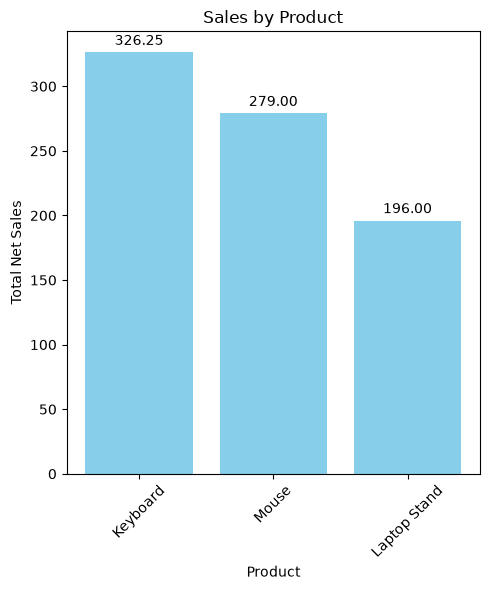

In [70]:
#plot sales by product
import matplotlib.pyplot as plt
plt.figure(figsize=(5, 6))
plt.bar(df2['Product'], df2['Total Net Sales'], color='skyblue')    
plt.xlabel('Product')
plt.ylabel('Total Net Sales')
plt.title('Sales by Product')
plt.bar_label(plt.bar(df2['Product'], df2['Total Net Sales'], color='skyblue'), fmt='%.2f', padding=3,label_type='edge')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

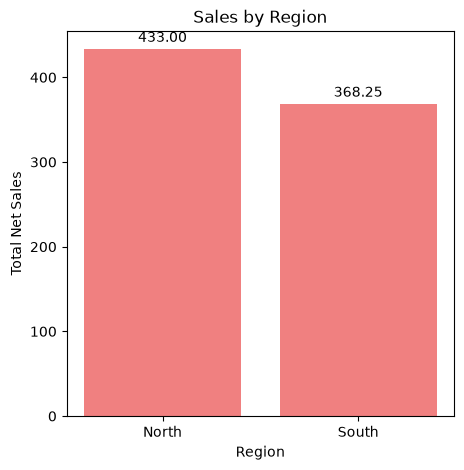

In [73]:
# sales by region
df_region = cleaned_df.groupby('Region')['Net_Sales'].sum().reset_index()
plt.figure(figsize=(5,5 ))
plt.bar(df_region['Region'], df_region['Net_Sales'], color='lightcoral')  
plt.bar_label(plt.bar(df_region['Region'], df_region['Net_Sales'], color='lightcoral'), fmt='%.2f', padding=3,label_type='edge')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Net Sales')
plt.show()

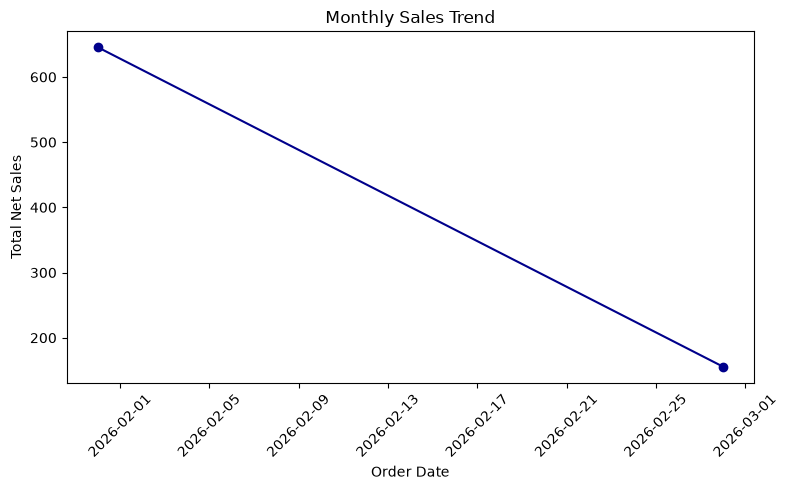

In [75]:
#monthly sales trend
df_monthly = cleaned_df.groupby(pd.Grouper(key='Order_Date', freq='ME'))['Net_Sales'].sum().reset_index()
plt.figure(figsize=(8, 5))  
plt.plot(df_monthly['Order_Date'], df_monthly['Net_Sales'], marker='o', linestyle='-', color='darkblue')
plt.bar_label
plt.title('Monthly Sales Trend')
plt.xlabel('Order Date')
plt.ylabel('Total Net Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()